# Radar / SAR Mission Planning

This notebook demonstrates how to plan synthetic aperture radar (SAR) missions
using HyPlan's `SidelookingRadar` sensor class and the three pre-configured
UAVSAR instrument definitions.

We cover:

1. Radar sensor fundamentals (frequency, resolution, swath geometry)
2. UAVSAR L-band, P-band, and Ka-band comparison
3. Swath width and ground-range resolution vs. altitude
4. Interferometric line spacing
5. Generating SAR flight lines and swath polygons


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Polygon

from hyplan.radar import SidelookingRadar, UAVSAR_Lband, UAVSAR_Pband, UAVSAR_Kaband
from hyplan.aircraft import NASA_C20A
from hyplan.flight_line import FlightLine
from hyplan.flight_box import box_around_polygon_terrain
from hyplan.swath import generate_swath_polygon, calculate_swath_widths
from hyplan.units import ureg

## 1. UAVSAR Instrument Overview

NASA/JPL's UAVSAR program flies three radar configurations on the
Gulfstream III (C-20A). Each operates at a different frequency band,
giving different penetration depths and resolution characteristics.

In [2]:
radars = {
    "L-band": UAVSAR_Lband(),
    "P-band": UAVSAR_Pband(),
    "Ka-band": UAVSAR_Kaband(),
}

rows = []
for label, r in radars.items():
    rows.append({
        "Radar": r.name,
        "Frequency (GHz)": f"{r.frequency.magnitude:.3f}",
        "Wavelength (cm)": f"{r.wavelength.to(ureg.cm).magnitude:.1f}",
        "Bandwidth (MHz)": f"{r.bandwidth.magnitude:.0f}",
        "Range Res (m)": f"{r.range_resolution.magnitude:.2f}",
        "Azimuth Res (m)": f"{r.azimuth_resolution.magnitude:.2f}",
        "Polarization": r.polarization,
        "Near Angle (deg)": r.near_range_angle,
        "Far Angle (deg)": r.far_range_angle,
    })

spec_df = pd.DataFrame(rows)
spec_df

,Radar,Frequency (GHz),Wavelength (cm),Bandwidth (MHz),Range Res (m),Azimuth Res (m),Polarization,Near Angle (deg),Far Angle (deg)
0,UAVSAR L-band,1.258,23.8,80,1.87,0.80,quad-pol,22.0,65.0
1,UAVSAR P-band (AirMOSS),0.430,69.7,20,7.49,0.80,quad-pol,25.0,45.0
2,UAVSAR Ka-band (GLISTIN-A),35.660,0.8,80,1.87,0.25,HH,15.0,50.0


## 2. Swath Geometry

Unlike nadir-looking line scanners, a side-looking radar's swath is
offset from the flight track. The swath is defined by the near-range
and far-range incidence angles. Let's visualize this.

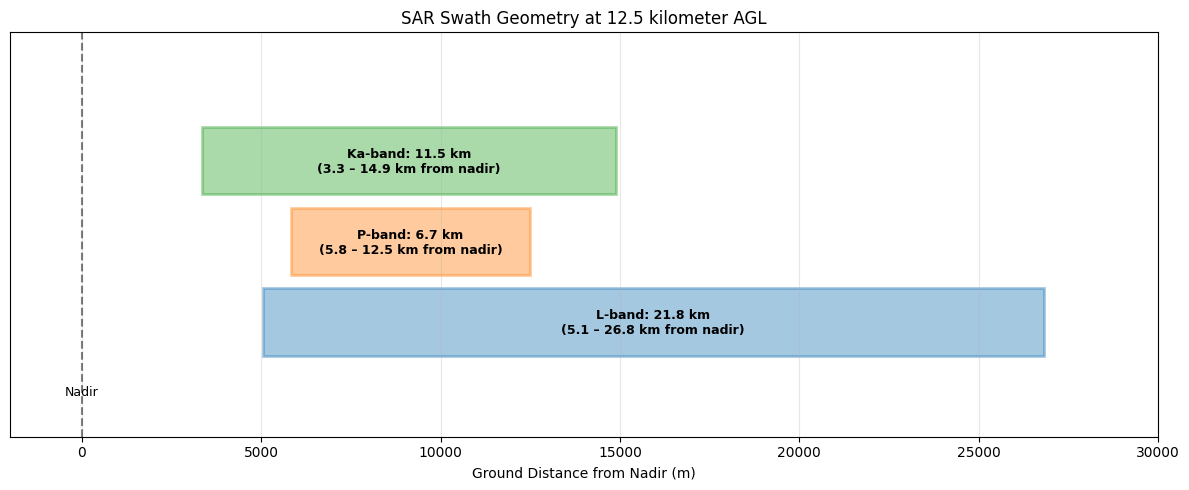

In [3]:
altitude = ureg.Quantity(12500, "meter")  # Typical UAVSAR altitude

fig, ax = plt.subplots(figsize=(12, 5))

colors = {"L-band": "#1f77b4", "P-band": "#ff7f0e", "Ka-band": "#2ca02c"}

for i, (label, r) in enumerate(radars.items()):
    near = r.near_range_ground_distance(altitude).magnitude
    far = r.far_range_ground_distance(altitude).magnitude
    swath = r.swath_width(altitude).magnitude
    y_offset = i * 0.3

    # Draw swath strip
    rect = mpatches.Rectangle(
        (near, y_offset), swath, 0.25,
        facecolor=colors[label], alpha=0.4, edgecolor=colors[label], linewidth=2,
    )
    ax.add_patch(rect)
    ax.text(
        (near + far) / 2, y_offset + 0.12,
        f"{label}: {swath/1000:.1f} km\n({near/1000:.1f} – {far/1000:.1f} km from nadir)",
        ha="center", va="center", fontsize=9, fontweight="bold",
    )

# Mark nadir
ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
ax.text(0, -0.15, "Nadir", ha="center", fontsize=9)

ax.set_xlim(-2000, 30000)
ax.set_ylim(-0.3, 1.2)
ax.set_xlabel("Ground Distance from Nadir (m)")
ax.set_title(f"SAR Swath Geometry at {altitude.to(ureg.km):.1f} AGL")
ax.set_yticks([])
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# The swath_offset_angles() method returns the viewing angles for each swath
# edge relative to nadir. This is the unified interface used by
# generate_swath_polygon() to handle both nadir and side-looking sensors.
#
# Convention: negative = port (left), positive = starboard (right)

print("Swath offset angles (degrees from nadir):\n")
print(f"{'Radar':<20s}  {'Look Dir':>9s}  {'Port Edge':>10s}  {'Stbd Edge':>10s}")
print(f"{'-'*20}  {'-'*9}  {'-'*10}  {'-'*10}")

for label, r in radars.items():
    port, stbd = r.swath_offset_angles()
    print(f"{r.name:<20s}  {r.look_direction:>9s}  {port:>9.1f}°  {stbd:>9.1f}°")

# A right-looking radar has positive angles (starboard side)
right_looking = SidelookingRadar(
    name="Right-looking test",
    frequency=1.26 * ureg.GHz, bandwidth=80 * ureg.MHz,
    near_range_angle=25.0, far_range_angle=60.0,
    azimuth_resolution=7 * ureg.meter, polarization="HH",
    look_direction="right",
)
port, stbd = right_looking.swath_offset_angles()
print(f"\n{right_looking.name:<20s}  {'right':>9s}  {port:>9.1f}°  {stbd:>9.1f}°")

Swath offset angles (degrees from nadir):

Radar                  Look Dir   Port Edge   Stbd Edge
--------------------  ---------  ----------  ----------
UAVSAR L-band              left      -65.0°      -22.0°
UAVSAR P-band (AirMOSS)       left      -45.0°      -25.0°
UAVSAR Ka-band (GLISTIN-A)       left      -50.0°      -15.0°

Right-looking test        right       25.0°       60.0°


## 3. Swath Width and Resolution vs. Altitude

SAR swath width scales linearly with altitude. Ground-range resolution
depends on the incidence angle (better at steeper angles near nadir).

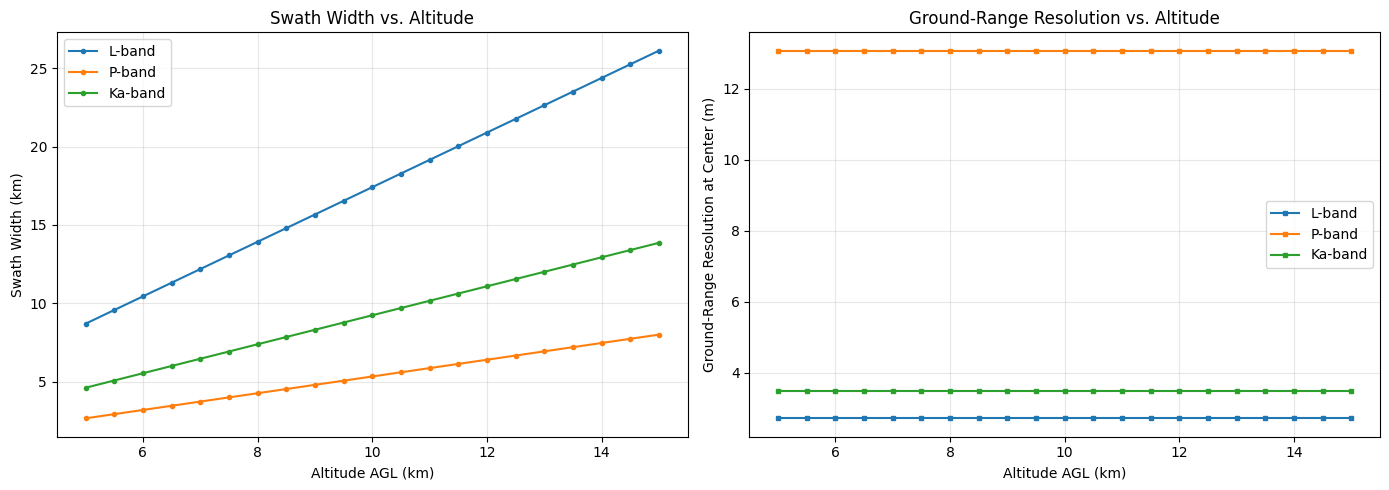

In [5]:
altitudes_m = np.arange(5000, 15001, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, r in radars.items():
    swaths = [r.swath_width(ureg.Quantity(a, "meter")).to(ureg.km).magnitude for a in altitudes_m]
    axes[0].plot(altitudes_m / 1000, swaths, "o-", markersize=3, label=label)

    # Ground-range resolution at swath center
    gnd_res = [
        r.ground_range_resolution(ureg.Quantity(a, "meter")).magnitude
        for a in altitudes_m
    ]
    axes[1].plot(altitudes_m / 1000, gnd_res, "s-", markersize=3, label=label)

axes[0].set_xlabel("Altitude AGL (km)")
axes[0].set_ylabel("Swath Width (km)")
axes[0].set_title("Swath Width vs. Altitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Altitude AGL (km)")
axes[1].set_ylabel("Ground-Range Resolution at Center (m)")
axes[1].set_title("Ground-Range Resolution vs. Altitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Ground Sample Distance Detail

SAR ground-range resolution varies across the swath — coarser at near range
(steeper angle, longer slant range) and finer at far range. The azimuth
resolution is constant and set by the antenna aperture.

In [6]:
altitude = ureg.Quantity(12500, "meter")

print(f"Ground sample distance at {altitude.to(ureg.km):.1f} AGL:\n")
for label, r in radars.items():
    gsd = r.ground_sample_distance(altitude)
    print(f"{r.name}:")
    print(f"  Near range:  {gsd['near_range']:.2f}")
    print(f"  Center:      {gsd['center']:.2f}")
    print(f"  Far range:   {gsd['far_range']:.2f}")
    print(f"  Azimuth:     {gsd['azimuth']:.2f}")
    print(f"  Slant range: {r.slant_range(altitude):.0f}")
    print()

Ground sample distance at 12.5 kilometer AGL:

UAVSAR L-band:
  Near range:  5.00 meter
  Center:      2.72 meter
  Far range:   2.07 meter
  Azimuth:     0.80 meter
  Slant range: 17232 meter

UAVSAR P-band (AirMOSS):
  Near range:  17.73 meter
  Center:      13.07 meter
  Far range:   10.60 meter
  Azimuth:     0.80 meter
  Slant range: 15260 meter

UAVSAR Ka-band (GLISTIN-A):
  Near range:  7.24 meter
  Center:      3.49 meter
  Far range:   2.45 meter
  Azimuth:     0.25 meter
  Slant range: 14821 meter



## 5. Interferometric Line Spacing

For repeat-pass InSAR or mosaicking, parallel flight lines must be
spaced so that their swaths overlap by a specified fraction.

In [7]:
altitude = ureg.Quantity(12500, "meter")
overlaps = [0.0, 0.1, 0.2, 0.5]

rows = []
for label, r in radars.items():
    for ov in overlaps:
        spacing = r.interferometric_line_spacing(altitude, overlap_fraction=ov)
        rows.append({
            "Radar": label,
            "Overlap": f"{ov:.0%}",
            "Swath (km)": f"{r.swath_width(altitude).to(ureg.km).magnitude:.1f}",
            "Line Spacing (km)": f"{spacing.to(ureg.km).magnitude:.1f}",
        })

spacing_df = pd.DataFrame(rows)
print(f"Line spacing at {altitude.to(ureg.km):.1f} AGL:\n")
spacing_df

Line spacing at 12.5 kilometer AGL:



,Radar,Overlap,Swath (km),Line Spacing (km)
0,L-band,0%,21.8,21.8
1,L-band,10%,21.8,19.6
2,L-band,20%,21.8,17.4
3,L-band,50%,21.8,10.9
4,P-band,0%,6.7,6.7
5,P-band,10%,6.7,6.0
6,P-band,20%,6.7,5.3
7,P-band,50%,6.7,3.3
8,Ka-band,0%,11.5,11.5
9,Ka-band,10%,11.5,10.4


## 6. Custom Radar Sensor

You can define your own side-looking radar by instantiating
`SidelookingRadar` directly with custom parameters.

In [8]:
custom_sar = SidelookingRadar(
    name="My X-band SAR",
    frequency=9.6 * ureg.GHz,
    bandwidth=150 * ureg.MHz,
    near_range_angle=20.0,
    far_range_angle=55.0,
    azimuth_resolution=1.0 * ureg.meter,
    polarization="HH",
    look_direction="right",
)

alt = ureg.Quantity(8000, "meter")
print(f"{custom_sar.name}:")
print(f"  Wavelength:      {custom_sar.wavelength.to(ureg.cm):.1f}")
print(f"  Range resolution: {custom_sar.range_resolution:.2f}")
print(f"  Swath width:     {custom_sar.swath_width(alt).to(ureg.km):.1f}")
print(f"  Look direction:  {custom_sar.look_direction}")

My X-band SAR:
  Wavelength:      3.1 centimeter
  Range resolution: 1.00 meter
  Swath width:     8.5 kilometer
  Look direction:  right


## 7. SAR Flight Lines and Swath Polygons

Generate a flight line and compute its SAR swath polygon on the ground.
The swath is offset to one side of the track (left for standard UAVSAR).

In [9]:
# Flight line over Southern California (typical UAVSAR flight)
fl = FlightLine.center_length_azimuth(
    lat=34.2, lon=-118.5,
    length=ureg.Quantity(80, "km"),
    az=350.0,
    altitude_msl=ureg.Quantity(41000, "feet"),  # ~12,500 m
    site_name="UAVSAR LA Basin",
)

lband = UAVSAR_Lband()
swath = generate_swath_polygon(fl, lband)
widths = calculate_swath_widths(swath)

print(f"Flight line: {fl.site_name}")
print(f"  Length: {fl.length.to(ureg.km):.1f}")
print(f"  Heading: {fl.az12.magnitude:.1f} deg")
print(f"  Altitude: {fl.altitude_msl}")
print(f"\nSwath widths:")
print(f"  Min:  {widths['min_width']:.0f} m")
print(f"  Mean: {widths['mean_width']:.0f} m")
print(f"  Max:  {widths['max_width']:.0f} m")

/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Flight line: UAVSAR LA Basin
  Length: 80.0 kilometer
  Heading: 350.0 deg
  Altitude: 12496.799999999997 meter

Swath widths:
  Min:  19544 m
  Mean: 21318 m
  Max:  21914 m


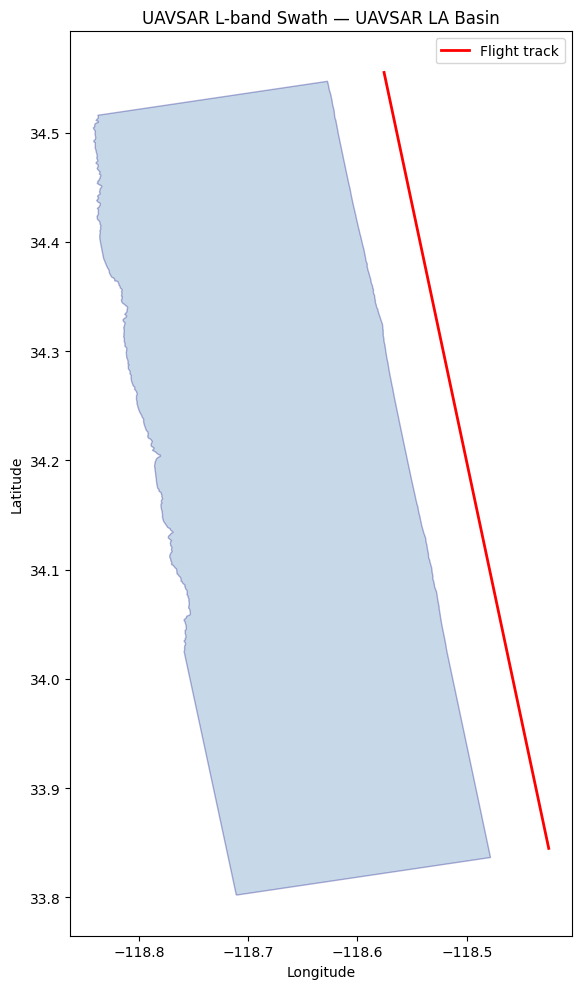

In [10]:
# Visualize flight line and swath
fig, ax = plt.subplots(figsize=(8, 10))

gpd.GeoSeries([swath]).plot(ax=ax, alpha=0.3, color="steelblue", edgecolor="navy")
x, y = fl.geometry.xy
ax.plot(x, y, "r-", linewidth=2, label="Flight track")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"UAVSAR L-band Swath — {fl.site_name}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Multi-Line SAR Coverage

Plan parallel flight lines for mosaicking with 10% swath overlap,
using interferometric line spacing.

Line spacing for 10% overlap: 19.6 kilometer


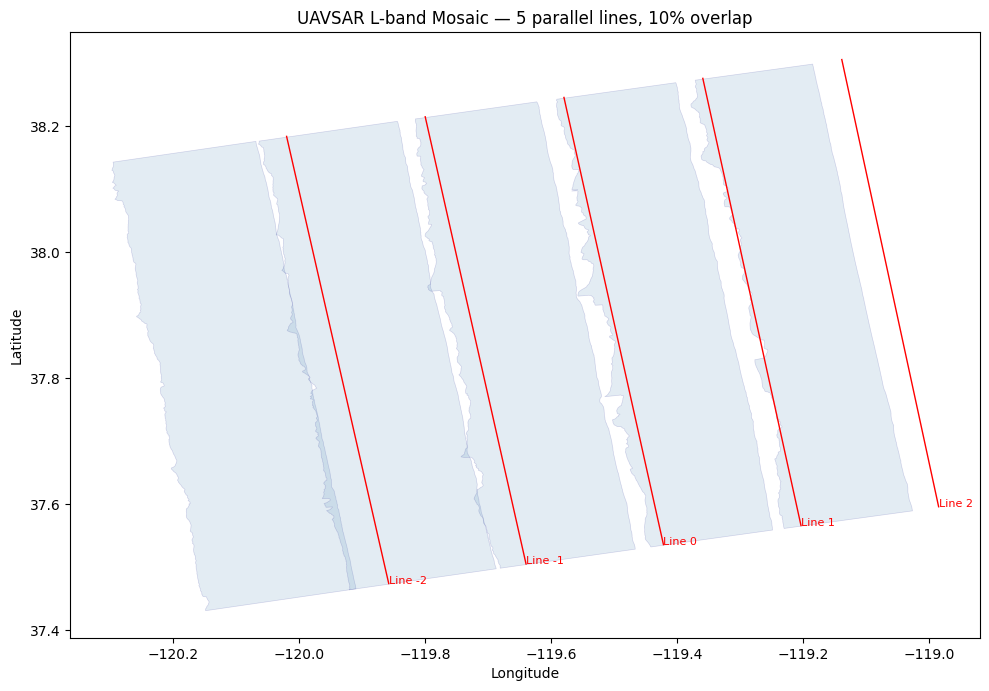

In [11]:
# Compute line spacing for 10% overlap
alt_agl = ureg.Quantity(12500, "meter")
spacing = lband.interferometric_line_spacing(alt_agl, overlap_fraction=0.10)
print(f"Line spacing for 10% overlap: {spacing.to(ureg.km):.1f}")

# Generate parallel lines offset from center
center_line = FlightLine.center_length_azimuth(
    lat=37.89, lon=-119.5,
    length=ureg.Quantity(80, "km"),
    az=350.0,
    altitude_msl=ureg.Quantity(41000, "feet"),
    site_name="Line 0",
)

lines = []
for i in range(-2, 3):
    offset_fl = center_line.offset_across(spacing * i)
    offset_fl.site_name = f"Line {i}"
    lines.append(offset_fl)

# Plot all lines and their swaths
fig, ax = plt.subplots(figsize=(10, 10))

for fl_line in lines:
    sw = generate_swath_polygon(fl_line, lband)
    gpd.GeoSeries([sw]).plot(ax=ax, alpha=0.15, color="steelblue", edgecolor="navy", linewidth=0.5)
    lx, ly = fl_line.geometry.xy
    ax.plot(lx, ly, "r-", linewidth=1)
    ax.annotate(fl_line.site_name, xy=(lx[0], ly[0]), fontsize=8, color="red")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"UAVSAR L-band Mosaic — 5 parallel lines, 10% overlap")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 9. Coverage Planning with box_around_polygon_terrain

`box_around_polygon_terrain` derives parallel flight lines from a study area
polygon and places them with terrain-aware spacing. At each candidate line
position it calls `generate_swath_polygon` with a real DEM to compute the
actual terrain-projected swath width, then steps by
`min_swath_width × (1 − overlap)`. This ensures the requested overlap is
maintained even over rugged terrain.

The function accepts both `LineScanner` and `SidelookingRadar` — the caller
provides `altitude_msl` directly.

Generated 7 flight lines
  UAVSAR_SN_L01_FL410: 90.2 kilometer, heading 349.8°
  UAVSAR_SN_L02_FL410: 90.2 kilometer, heading 349.9°
  UAVSAR_SN_L03_FL410: 90.1 kilometer, heading 350.0°
  UAVSAR_SN_L04_FL410: 90.1 kilometer, heading 350.1°
  UAVSAR_SN_L05_FL410: 90.1 kilometer, heading 350.2°
  UAVSAR_SN_L06_FL410: 90.1 kilometer, heading 350.2°
  UAVSAR_SN_L07_FL410: 90.0 kilometer, heading 350.3°


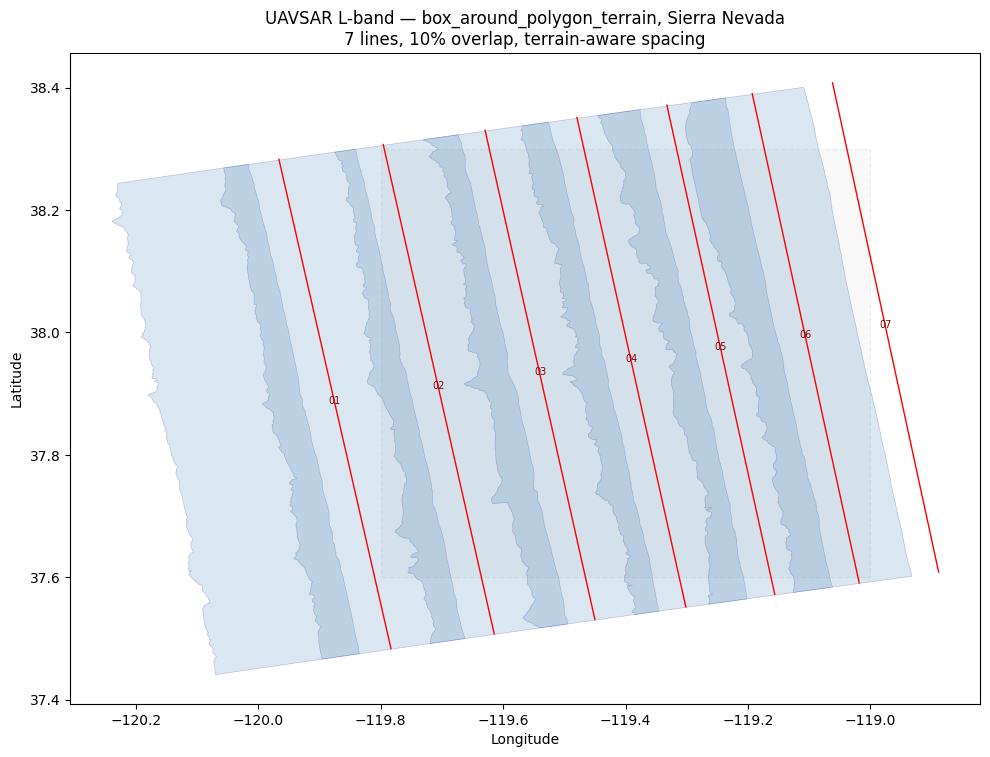

In [15]:
# Study area: Sierra Nevada (rugged terrain — good test for terrain-aware spacing)
study_area = Polygon([
    (-119.8, 37.6),
    (-119.0, 37.6),
    (-119.0, 38.3),
    (-119.8, 38.3),
])

lband = UAVSAR_Lband()
altitude = ureg.Quantity(41000, "feet")  # ~12,500 m MSL

sar_lines = box_around_polygon_terrain(
    instrument=lband,
    altitude_msl=altitude,
    polygon=study_area,
    azimuth=350.0,
    box_name="UAVSAR_SN",
    overlap=20,
    clip_to_polygon=False,
    alternate_direction=False
)

print(f"Generated {len(sar_lines)} flight lines")
for fl_line in sar_lines:
    print(f"  {fl_line.site_name}: {fl_line.length.to(ureg.km):.1f}, heading {fl_line.az12.magnitude:.1f}°")

# Visualize: flight lines + terrain-projected swath footprints
fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries([study_area]).plot(
    ax=ax, alpha=0.05, color="gray", edgecolor="black", linestyle="--", linewidth=1,
)

for fl_line in sar_lines:
    sw = generate_swath_polygon(fl_line, lband)
    gpd.GeoSeries([sw]).plot(ax=ax, alpha=0.2, color="steelblue", edgecolor="navy", linewidth=0.5)
    lx, ly = fl_line.geometry.xy
    ax.plot(lx, ly, "r-", linewidth=1)
    label = fl_line.site_name.split("_L")[1].split("_")[0]
    ax.annotate(label, xy=(np.mean(lx), np.mean(ly)), fontsize=7, color="darkred", ha="center")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"UAVSAR L-band — box_around_polygon_terrain, Sierra Nevada\n"
    f"{len(sar_lines)} lines, 20% overlap, terrain-aware spacing"
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 10. FAA L-Band Radar Exclusion Zone Check

UAVSAR L-Band operations must stay outside a 10 nautical mile radius of each
FAA long-range L-Band radar site to avoid interference. `check_lband_radar_exclusions`
loads the pre-bundled exclusion zone polygons and flags any swath that intersects them.

A clean flight plan returns an empty list. Any intersection is reported as a
`RadarExclusionConflict` with the site name, swath index, and the overlap geometry.

In [ ]:
from hyplan.radar import check_lband_radar_exclusions

# Check the LA Basin swath generated in Section 7
conflicts = check_lband_radar_exclusions(swath)
if conflicts:
    for c in conflicts:
        print(f"  CONFLICT: {c.radar_name} (swath index {c.swath_index})")
else:
    print("LA Basin swath: no FAA L-Band radar conflicts \u2713")

# Demonstrate a conflict: flight line through the AJO, AZ exclusion zone
# (FAA L-Band radar site at 32.43°N, 112.95°W)
fl_ajo = FlightLine.center_length_azimuth(
    lat=32.43, lon=-112.95,
    length=ureg.Quantity(80, "km"),
    az=0.0,
    altitude_msl=ureg.Quantity(41000, "feet"),
    site_name="AJO exclusion zone demo",
)

swath_ajo = generate_swath_polygon(fl_ajo, lband)
conflicts_ajo = check_lband_radar_exclusions(swath_ajo)

print(f"\nAJO demo swath: {len(conflicts_ajo)} conflict(s) detected")
for c in conflicts_ajo:
    print(f"  Radar site: {c.radar_name}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: LA Basin — clean swath
ax = axes[0]
gpd.GeoSeries([swath]).plot(ax=ax, alpha=0.3, color="steelblue", edgecolor="navy")
lx, ly = fl.geometry.xy
ax.plot(lx, ly, "r-", linewidth=2, label="Flight track")
ax.set_title("LA Basin — No Conflicts")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: AJO demo — conflict
ax = axes[1]
for c in conflicts_ajo:
    gpd.GeoSeries([c.exclusion_zone]).plot(
        ax=ax, alpha=0.15, color="red", edgecolor="red", linewidth=2
    )
    gpd.GeoSeries([c.intersection]).plot(
        ax=ax, alpha=0.6, color="orange", edgecolor="darkorange", linewidth=1.5
    )
gpd.GeoSeries([swath_ajo]).plot(ax=ax, alpha=0.3, color="steelblue", edgecolor="navy")
lx, ly = fl_ajo.geometry.xy
ax.plot(lx, ly, "r-", linewidth=2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.4, label="UAVSAR swath"),
    Patch(facecolor="red", alpha=0.3, label="Exclusion zone (10 NMI)"),
    Patch(facecolor="orange", alpha=0.7, label="Conflict area"),
    plt.Line2D([0], [0], color="red", linewidth=2, label="Flight track"),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_title(f"AJO Exclusion Zone — {len(conflicts_ajo)} Conflict(s)")
ax.set_xlabel("Longitude")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.suptitle("FAA L-Band Radar Exclusion Zone Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

| Feature | Class/Function | Purpose |
|---------|---------------|----------|
| Radar definition | `SidelookingRadar` | Custom SAR with frequency, angles, resolution |
| Pre-configured | `UAVSAR_Lband`, `UAVSAR_Pband`, `UAVSAR_Kaband` | NASA/JPL UAVSAR variants |
| Swath offset angles | `swath_offset_angles()` | Unified interface for swath edge viewing angles |
| Swath geometry | `swath_width()`, `near/far_range_ground_distance()` | Offset swath calculation |
| Resolution | `ground_sample_distance()`, `ground_range_resolution()` | Range and azimuth GSD |
| InSAR planning | `interferometric_line_spacing()` | Parallel line spacing with overlap |
| Swath polygon | `generate_swath_polygon()` | Ground footprint for flight lines |
| Coverage planning | `box_around_polygon_terrain()` | Terrain-aware parallel lines from study area polygon |